In [2]:
# 04_family_kmeans.ipynb

# 1. DATA LOADING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the preprocessed dataset
df = pd.read_csv("preprocessed_customer_data.csv")

In [3]:
# 2. FEATURE SELECTION (FAMILY BEHAVIOR)

# Focus on family structure and spending habits
family_features = [
    'Kidhome', 'Teenhome', 'MntMeatProducts', 'MntFruits',
    'MntSweetProducts', 'MntFishProducts'
]
X = df[family_features]

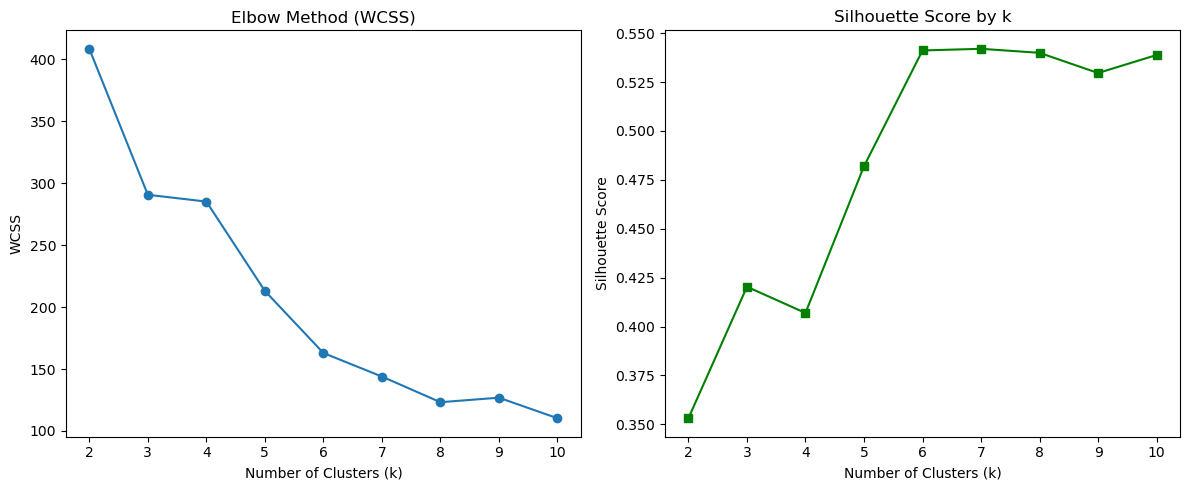

In [4]:
# 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (k)

wcss = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Elbow and Silhouette Score
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(k_values, wcss, marker='o')
ax[0].set_title("Elbow Method (WCSS)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("WCSS")

ax[1].plot(k_values, silhouette_scores, marker='s', color='green')
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [8]:
# 4. APPLY K-MEANS CLUSTERING

optimal_k = 6  # Choose based on elbow/silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['FamilyCluster_KMeans'] = kmeans.fit_predict(X)

score = silhouette_score(X, df['FamilyCluster_KMeans'])
print(f"Silhouette Score (k={optimal_k}): {score:.4f}")

Silhouette Score (k=6): 0.5411



📊 Average Family & Product Spending per Cluster:


,Kidhome,Teenhome,MntMeatProducts,MntFruits,MntSweetProducts,MntFishProducts
FamilyCluster_KMeans,,,,,,
0,0.516865,0.000000,0.026213,0.043960,0.031246,0.043459
1,0.000000,0.000000,0.167890,0.127213,0.126170,0.150688
2,0.210000,1.000000,0.067200,0.080402,0.051832,0.072046
3,0.000000,0.500000,0.071342,0.097221,0.079852,0.097312
4,0.536616,0.500000,0.024777,0.028806,0.025204,0.031356
5,0.018927,0.102524,0.261164,0.479337,0.335794,0.539237


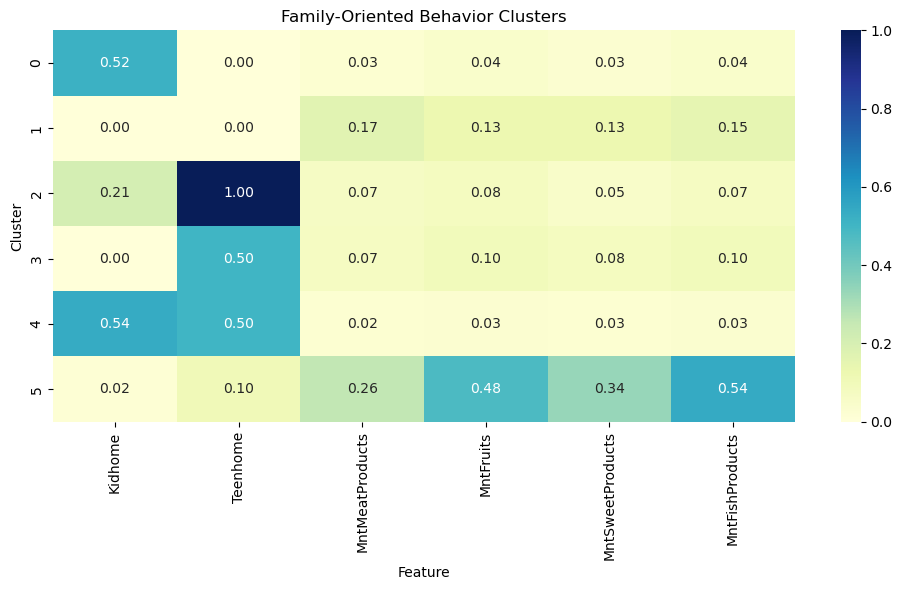

In [10]:
# 5. CLUSTER PROFILE ANALYSIS

cluster_profile = df.groupby('FamilyCluster_KMeans')[family_features].mean()
print("\n📊 Average Family & Product Spending per Cluster:")
display(cluster_profile)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Family-Oriented Behavior Clusters")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

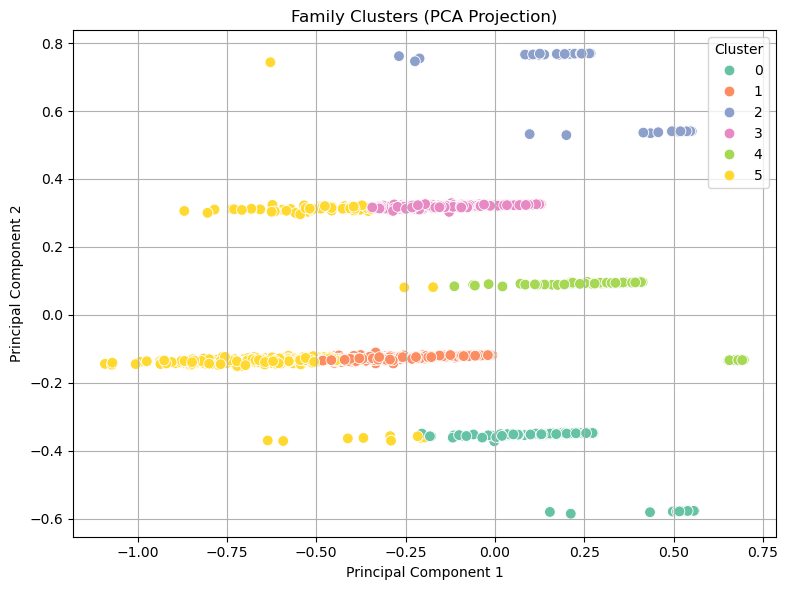

In [12]:
# 6. VISUALIZE CLUSTERS USING PCA (2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['FamilyCluster_KMeans']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title("Family Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()